# $\Sigma^\mathrm{prj}(R \,|\, \lambda^\mathrm{ob}, z^\mathrm{ob})$

The projected surface density of the miscentered NFW halo profile,
convolved with the angular selection bias $b_\text{sel}(\theta)$ and
the nonlinear correlation $\xi_\mathrm{NL}(r, z)$, evaluated at one
(or several) $(\lambda^\text{ob}, z^\text{ob})$ bin centres.

In [1]:
%%time
import numpy as np
import matplotlib.pyplot as plt

from richness_selection import (
    Cosmology, PkGrid, HMF, Bias, MOR, XiNL, NFWMiscentered, SelBias, SigmaPrj,
)
from richness_selection.sigma_m import SigmaM

cosmo    = Cosmology()
pk       = PkGrid(cosmo)
sigma_m  = SigmaM(pk)
hmf      = HMF(sigma_m)
bias     = Bias(sigma_m)
mor      = MOR()
xi_nl = XiNL(cosmo)
sel_bias = SelBias(cosmo, pk, hmf, bias, mor, xi_nl=xi_nl)
nfw      = NFWMiscentered(cosmo)
sigma_prj = SigmaPrj(cosmo, sel_bias, nfw)

CPU times: user 4.52 s, sys: 825 ms, total: 5.34 s
Wall time: 2.7 s


## Sigma_prj(R) at $(\lambda^\text{ob}=20, z^\text{ob}=0.5)$

Sigma_prj(20 R): 4780.2 ms


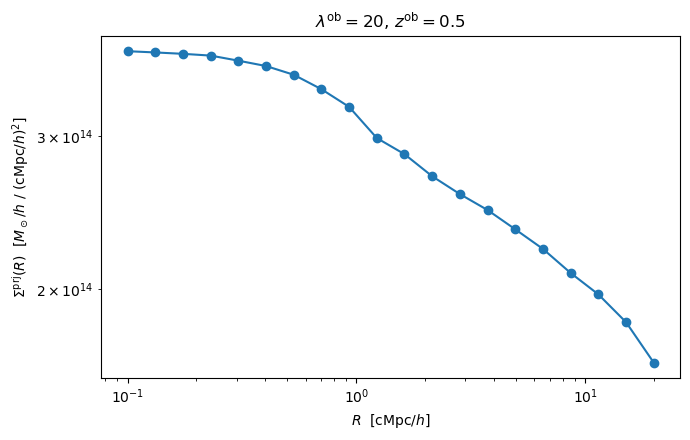

CPU times: user 12.5 s, sys: 157 ms, total: 12.6 s
Wall time: 5.19 s


In [2]:
%%time
import time

R = np.logspace(-1, 1.3, 20)    # 0.1 - 20 cMpc/h
t0 = time.perf_counter()
prof = sigma_prj(R, lob=20.0, zob=0.5)
print(f'Sigma_prj(20 R): {(time.perf_counter() - t0) * 1e3:.1f} ms')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(R, prof, 'o-', color='C0')
ax.set_xlabel(r'$R$  [cMpc/$h$]')
ax.set_ylabel(r'$\Sigma^\mathrm{prj}(R)$  [$M_\odot/h$ / (cMpc/$h$)$^2$]')
ax.set_title(r'$\lambda^\mathrm{ob}=20$, $z^\mathrm{ob}=0.5$')
fig.tight_layout()
plt.show()

## Richness-bin comparison at $z^\mathrm{ob}=0.5$

lob= 10.0: 2298.4 ms


lob= 20.0: 2047.8 ms


lob= 40.0: 2272.4 ms


lob= 80.0: 2271.8 ms


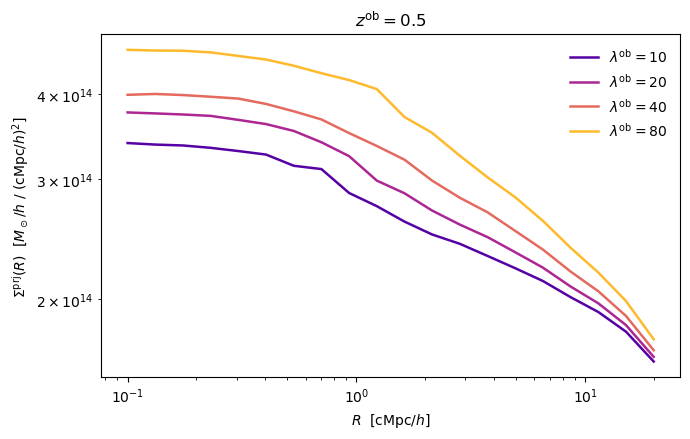

CPU times: user 9.13 s, sys: 103 ms, total: 9.23 s
Wall time: 9.27 s


In [3]:
%%time
lob_bins = [10.0, 20.0, 40.0, 80.0]
R = np.logspace(-1, 1.3, 20)

fig, ax = plt.subplots(figsize=(7, 4.5))
cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(lob_bins)))
for col, lob in zip(cmap, lob_bins):
    t0 = time.perf_counter()
    prof = sigma_prj(R, lob=lob, zob=0.5)
    print(f'lob={lob:5.1f}: {(time.perf_counter()-t0)*1e3:6.1f} ms')
    ax.loglog(R, prof, color=col, lw=1.8,
              label=rf'$\lambda^\mathrm{{ob}}={lob:.0f}$')

ax.set_xlabel(r'$R$  [cMpc/$h$]')
ax.set_ylabel(r'$\Sigma^\mathrm{prj}(R)$  [$M_\odot/h$ / (cMpc/$h$)$^2$]')
ax.legend(frameon=False)
ax.set_title(r'$z^\mathrm{ob}=0.5$')
fig.tight_layout()
plt.show()

## Redshift-bin comparison at $\lambda^\mathrm{ob}=20$

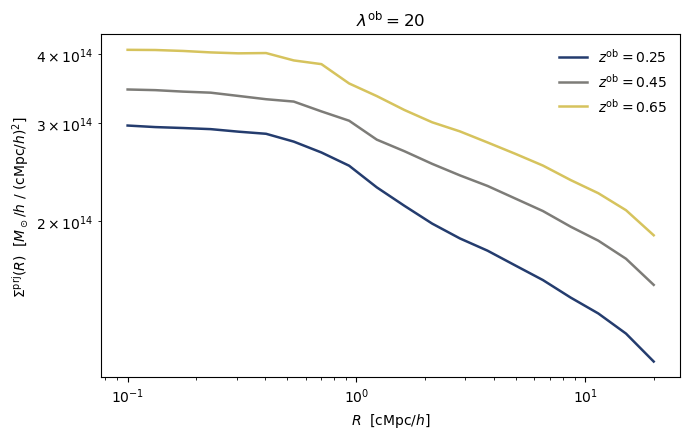

CPU times: user 7.06 s, sys: 144 ms, total: 7.21 s
Wall time: 7.25 s


In [4]:
%%time
zob_bins = [0.25, 0.45, 0.65]
R = np.logspace(-1, 1.3, 20)

fig, ax = plt.subplots(figsize=(7, 4.5))
cmap = plt.cm.cividis(np.linspace(0.15, 0.85, len(zob_bins)))
for col, zob in zip(cmap, zob_bins):
    prof = sigma_prj(R, lob=20.0, zob=zob)
    ax.loglog(R, prof, color=col, lw=1.8,
              label=rf'$z^\mathrm{{ob}}={zob:.2f}$')

ax.set_xlabel(r'$R$  [cMpc/$h$]')
ax.set_ylabel(r'$\Sigma^\mathrm{prj}(R)$  [$M_\odot/h$ / (cMpc/$h$)$^2$]')
ax.legend(frameon=False)
ax.set_title(r'$\lambda^\mathrm{ob}=20$')
fig.tight_layout()
plt.show()